In [15]:
import sys
import os
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sys.path.append(os.path.abspath('../src'))

from classification_calculations import fetch_pam50_centroids
pam50_centroids = fetch_pam50_centroids()
master_df = pd.read_csv("../data/processed/tcga_master_results.csv", index_col=0)

/var/folders/rp/2xgdv92s5nd4p9c5rl3nrjvr0000gn/T/ipykernel_13146/1623637996.py:19: DtypeWarning: Columns (9,10,11,12,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  master_df = pd.read_csv("../data/processed/tcga_master_results.csv", index_col=0)


### Individual Kaplan-meier graphs

In [16]:
# This will search all 20,000+ columns and print only the ones related to survival or time
for col in master_df.columns:
    if 'time' in col.lower() or 'status' in col.lower() or 'days' in col.lower() or 'surv' in col.lower() or 'vital' in col.lower():
        print(col)

ER.Status
PR.Status
HER2.Status
Median_overall_survival
overall_survival
status
overallsurvival
TIMELESS


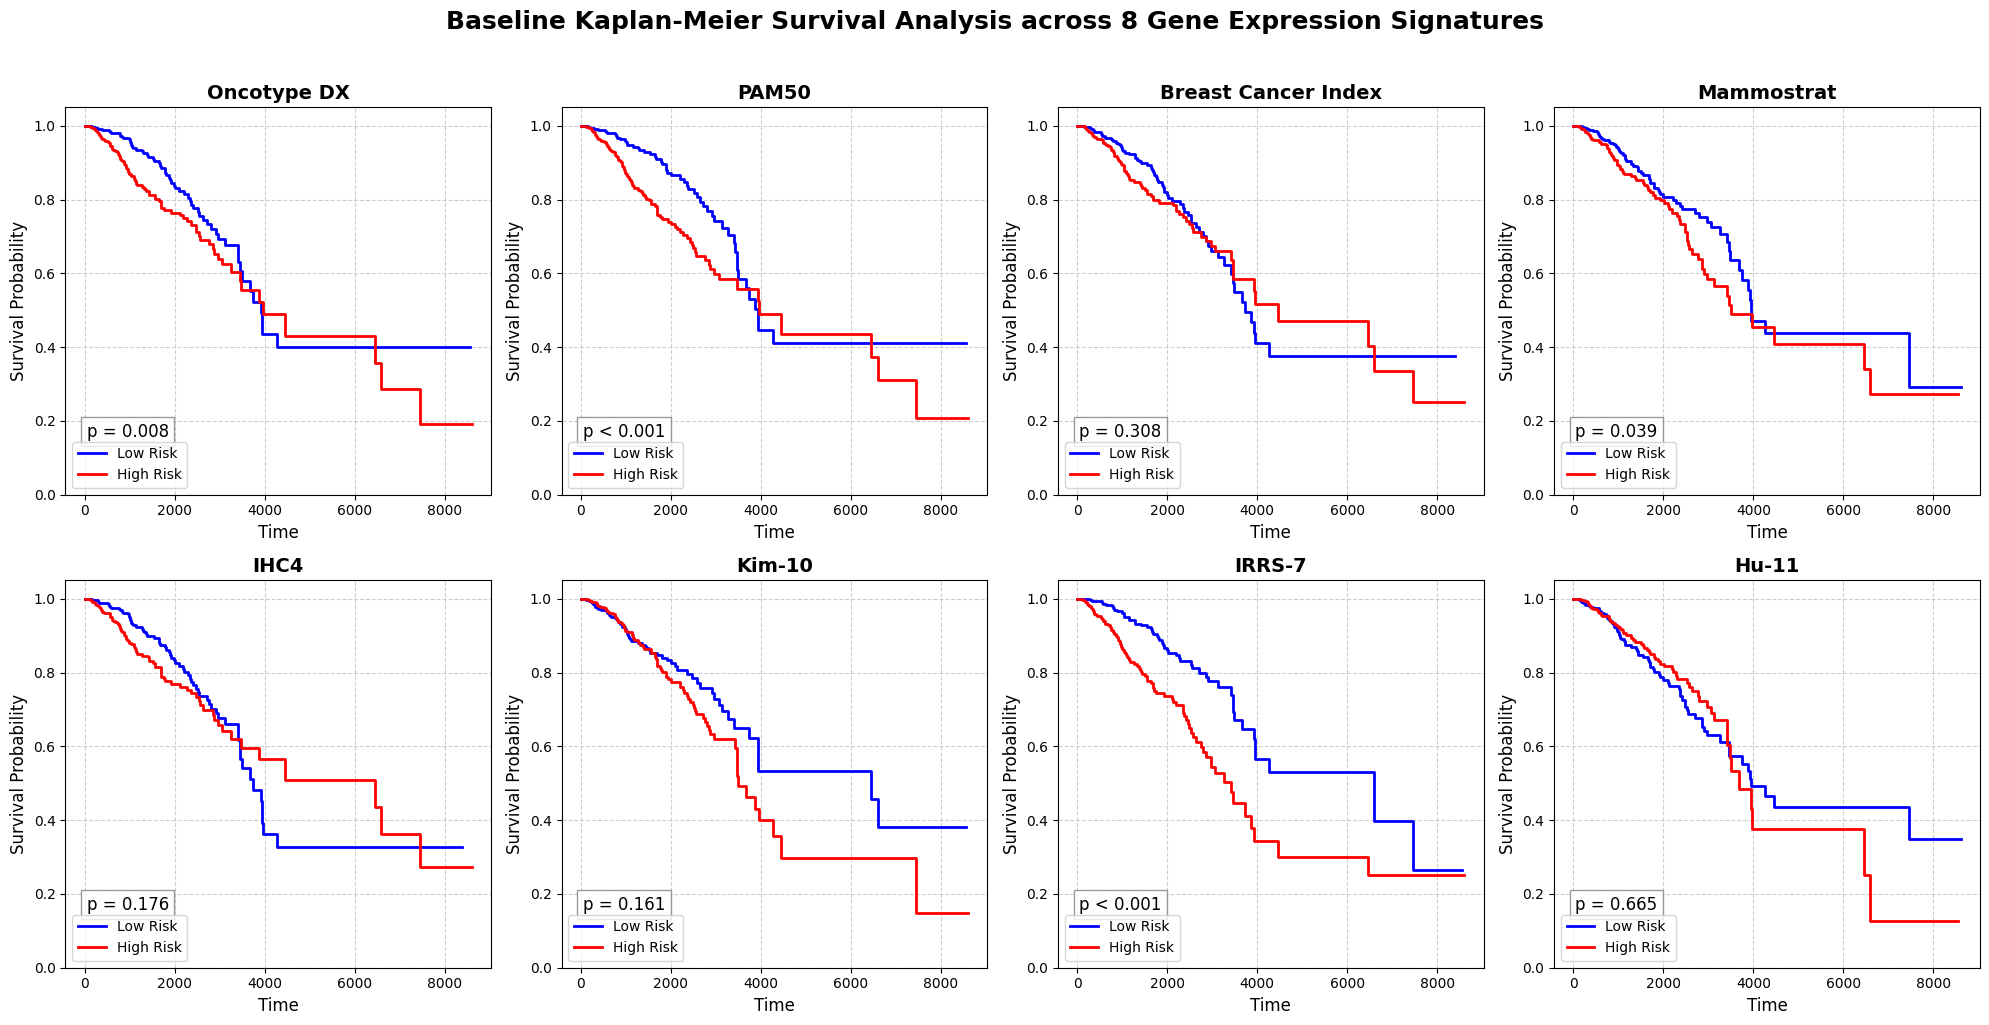

In [17]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# 1. Define your clinical columns (Update these to match your TCGA-BRCA column names!)
TIME_COL = 'overall_survival'  
EVENT_COL = 'status'
# 2. List the exact column names of your 8 binarised classifications
signatures = [
    'OncotypeDX_Class', # Added the DX
    'Pam50_Class',      # Changed to lowercase 'am'
    'BCI_Class', 
    'Mammostrat_Class',
    'IHC4_Class', 
    'Kim10_Class', 
    'IRRS7_Class', 
    'Hu11_Class'
]

# Display names for the graph titles to make them look professional
display_names = [
    'Oncotype DX', 'PAM50', 'Breast Cancer Index', 'Mammostrat',
    'IHC4', 'Kim-10', 'IRRS-7', 'Hu-11'
]

# 3. Setup the 2x4 Grid Figure
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten() # Flattens the 2D array of axes for easy looping
kmf = KaplanMeierFitter()

# Drop patients missing survival data so lifelines doesn't crash
clean_df = master_df.dropna(subset=[TIME_COL, EVENT_COL])

# 4. Loop through each signature and plot
for i, sig in enumerate(signatures):
    ax = axes[i]
    
    # Isolate High Risk (1) and Low Risk (0) patients
    high_mask = clean_df[sig] == 1
    low_mask = clean_df[sig] == 0
    
    # Calculate Log-Rank p-value to prove statistical significance
    results = logrank_test(
        clean_df[TIME_COL][high_mask], clean_df[TIME_COL][low_mask],
        event_observed_A=clean_df[EVENT_COL][high_mask], 
        event_observed_B=clean_df[EVENT_COL][low_mask]
    )
    p_val = results.p_value
    
    # Plot Low Risk
    kmf.fit(clean_df[TIME_COL][low_mask], clean_df[EVENT_COL][low_mask], label='Low Risk')
    kmf.plot_survival_function(ax=ax, color='blue', ci_show=False, linewidth=2)
    
    # Plot High Risk
    kmf.fit(clean_df[TIME_COL][high_mask], clean_df[EVENT_COL][high_mask], label='High Risk')
    kmf.plot_survival_function(ax=ax, color='red', ci_show=False, linewidth=2)
    
    # Formatting the subplot
    ax.set_title(display_names[i], fontsize=14, fontweight='bold')
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Survival Probability', fontsize=12)
    ax.set_ylim([0.0, 1.05])
    
    # Add the p-value text directly onto the plot
    # Formats p < 0.001 nicely, otherwise shows the exact value
    p_text = 'p < 0.001' if p_val < 0.001 else f'p = {p_val:.3f}'
    ax.text(0.05, 0.15, p_text, transform=ax.transAxes, fontsize=12, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='lower left')

# 5. Final Polish and Save
plt.suptitle('Baseline Kaplan-Meier Survival Analysis across 8 Gene Expression Signatures', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the exact image name we referenced in your LaTeX file!
# plt.savefig('images/individual_km_curves.png', dpi=300, bbox_inches='tight')
plt.show()

### Sankey Diagram

In [18]:
import plotly.graph_objects as go
import pandas as pd

def generate_full_sankey(df, signatures):
    # 1. Define nodes (8 signatures * 2 classes = 16 nodes)
    # Each signature gets a "Low" and "High" node
    nodes = []
    for sig in signatures:
        nodes.extend([f"{sig}_Low", f"{sig}_High"])
    
    sources = []
    targets = []
    values = []
    
    # 2. Build links between consecutive signatures
    # We loop from the 1st signature to the 7th, linking each to the next one
    for i in range(len(signatures) - 1):
        sig_a = signatures[i]
        sig_b = signatures[i+1]
        
        # Calculate the 4 possible transitions between Sig A and Sig B
        # 0 -> 0 (Low to Low)
        # 0 -> 1 (Low to High)
        # 1 -> 0 (High to Low)
        # 1 -> 1 (High to High)
        for val_a in [0, 1]:
            for val_b in [0, 1]:
                count = df[(df[f'{sig_a}'] == val_a) & 
                           (df[f'{sig_b}'] == val_b)].shape[0]
                
                if count > 0:
                    # Logic for node indices: 
                    # Sig 0: Low=0, High=1 | Sig 1: Low=2, High=3...
                    sources.append(i*2 + val_a)
                    targets.append((i+1)*2 + val_b)
                    values.append(count)

    # 3. Create the figure
    fig = go.Figure(data=[go.Sankey(
        node = dict(
            pad = 20,
            thickness = 15,
            line = dict(color = "black", width = 0.5),
            label = nodes,
            color = "rgba(31, 119, 180, 0.8)" # Professional blue
        ),
        link = dict(
            source = sources,
            target = targets,
            value = values,
            color = "rgba(200, 200, 200, 0.4)" # Light grey for paths
        ))])

    fig.update_layout(
        title_text="Multi-Signature Risk Reclassification Flow",
        font_size=10,
        width=1200,
        height=600
    )
    
    fig.show()

# Run the function
generate_full_sankey(master_df, signatures)

### PCA Plot (Biological Space)

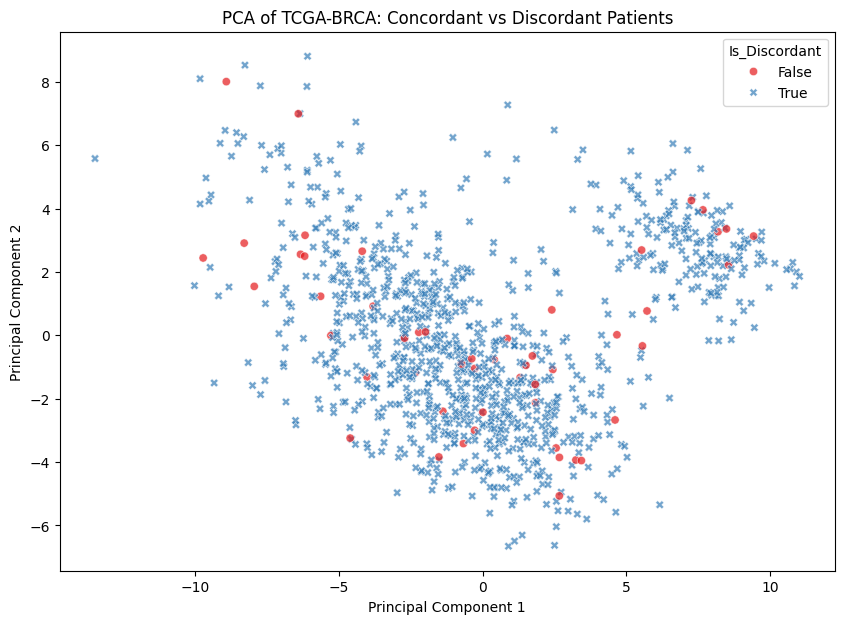

In [19]:
# 1. Prepare genetic data (Use the 50 PAM50 genes as a representative subset)
pca_genes = [g for g in pam50_centroids.index if g in master_df.columns]
x = master_df[pca_genes].values
x = StandardScaler().fit_transform(x)

# 2. Run PCA
pca = PCA(n_components=2)
components = pca.fit_transform(x)

# 3. Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=components[:,0], y=components[:,1], 
    hue=master_df['Is_Discordant'], 
    style=master_df['Is_Discordant'],
    palette='Set1', alpha=0.7
)
plt.title('PCA of TCGA-BRCA: Concordant vs Discordant Patients')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### Kaplan-Meier Survival Curves

In [20]:
print(master_df[['overall_survival', 'status']].head())

              overall_survival  status
TCGA.5L.AAT0            1477.0     0.0
TCGA.5L.AAT1            1471.0     0.0
TCGA.A1.A0SP             584.0     0.0
TCGA.A2.A04V            1920.0     1.0
TCGA.A2.A04Y            1099.0     0.0


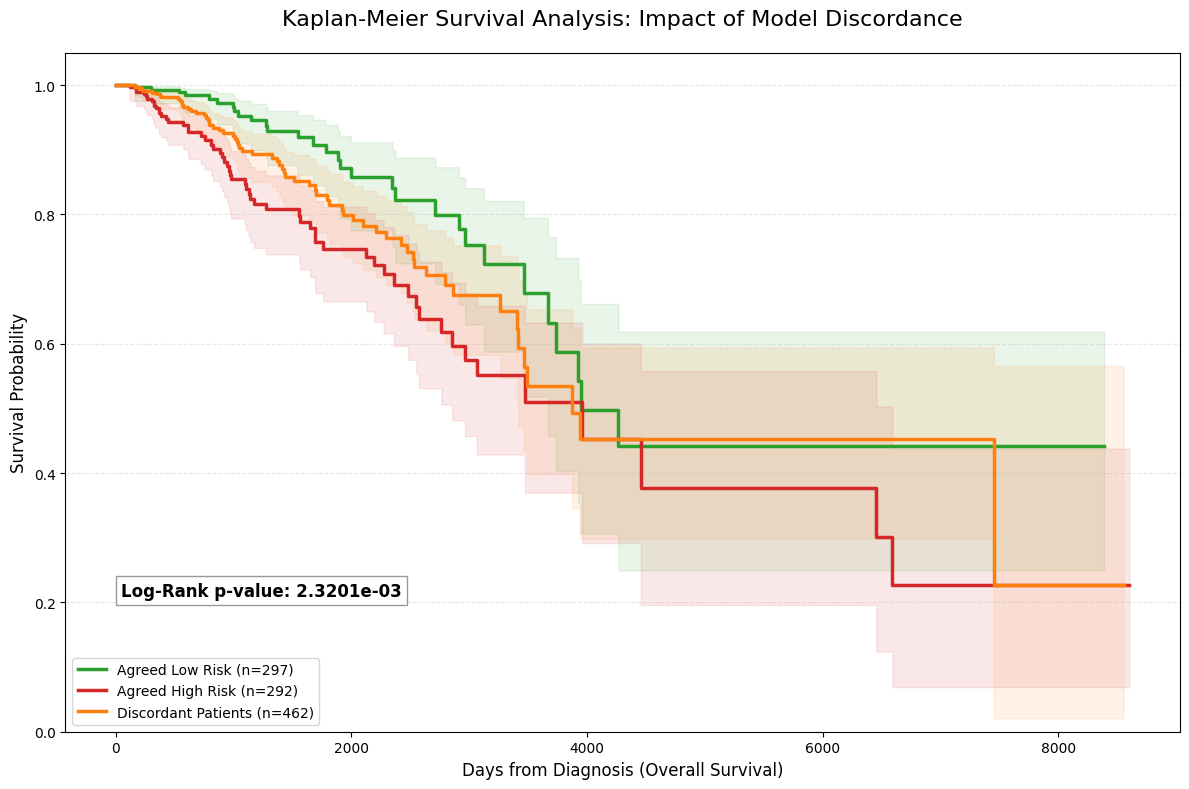

In [24]:
# 1. CLEANING: Remove patients missing vital survival data
# We use a copy so we don't affect your original master_df
plot_df = master_df.dropna(subset=['overall_survival', 'status']).copy()
plot_df['status'] = plot_df['status'].astype(int)

# 2. GROUPING: Define our three study cohorts
# def categorize_patient(row):
#     if not row['Is_Discordant']:
#         return 'Agreed Low' if row['OncotypeDX_Class'] == 0 else 'Agreed High'
#     return 'Discordant'

signatures = ['OncotypeDX', 'Pam50', 'BCI', 'Mammostrat', 'IHC4', 'Kim10', 'IRRS7', 'Hu11']
class_cols = [f'{sig}_Class' for sig in signatures]

def categorize_patient(row):
    # Count how many models flagged 'High Risk' (1)
    high_count = row[class_cols].sum()
    
    if high_count >= 6:
        return 'Agreed High'
    elif high_count <= 2:
        return 'Agreed Low'
    else:
        return 'Discordant'

plot_df['Thesis_Group'] = plot_df.apply(categorize_patient, axis=1)

# 3. STATISTICS: Calculate the Multivariate Log-Rank p-value
results = multivariate_logrank_test(
    plot_df['overall_survival'], 
    plot_df['Thesis_Group'], 
    plot_df['status']
)

# 4. VISUALISATION: Setup the KM Plot
kmf = KaplanMeierFitter()
plt.figure(figsize=(12, 8))

# Define groups and professional academic colours
groups = {
    'Agreed Low Risk': plot_df[plot_df['Thesis_Group'] == 'Agreed Low'],
    'Agreed High Risk': plot_df[plot_df['Thesis_Group'] == 'Agreed High'],
    'Discordant Patients': plot_df[plot_df['Thesis_Group'] == 'Discordant']
}
colors = ['#2ca02c', '#d62728', '#ff7f0e'] # Green, Red, Orange

# 5. EXECUTION: Fit and Plot each group
for (name, data), color in zip(groups.items(), colors):
    kmf.fit(data['overall_survival'], event_observed=data['status'], label=f"{name} (n={len(data)})")
    
    # A single call handles both the solid line and the shaded confidence interval
    # ci_alpha controls the shadow, linewidth controls the solid line
    kmf.plot_survival_function(color=color, linewidth=2.5, ci_alpha=0.1)

# 6. FORMATTING: Make it look like a journal publication
plt.title('Kaplan-Meier Survival Analysis: Impact of Model Discordance', fontsize=16, pad=20)
plt.xlabel('Days from Diagnosis (Overall Survival)', fontsize=12)
plt.ylabel('Survival Probability', fontsize=12)
plt.ylim(0, 1.05)
plt.legend(loc='lower left', frameon=True)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add the p-value result to the plot
plt.text(0.05, 0.2, f'Log-Rank p-value: {results.p_value:.4e}', 
         transform=plt.gca().transAxes, fontsize=12, fontweight='bold', 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

### Cox regression

Running Multivariate Cox on 1015 complete cases...


<lifelines.CoxPHFitter: fitted with 1015 total observations, 873 right-censored observations>
             duration col = 'overall_survival'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 1015
number of events observed = 142
   partial log-likelihood = -753.48
         time fit was run = 2026-05-16 12:26:29 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
Age                       0.04      1.04      0.01            0.03            0.05                1.03                1.05
Stage_Numeric             0.80      2.24      0.11            0.58            1.03                1.79                2.79
Thesis_Group_Agreed High  1.05      2.86      0.24            0.58            1.53                1.78                4.61
Thesis_Group_Discordant   0.47      1.61      0.24            0.00            0.94                1.00                2.57

                          cmp to    z      p  -log2(p)
covariate                                             
Age                         0.00 5.85 <0.005     27.58
Stage_Numeric               0.00 7.12 <0.005     39.78
Thesis_Group_Agreed High    0.00 4.33 <0.005     16.05
Thesis_Group_Discordant     0.00 1.98   0.05      4.39
---
Concordance = 0.77
Partial AIC = 1514.97
log-likelihood ratio test = 95.80 on 4 df
-log2(p) of ll-ratio test = 63.50

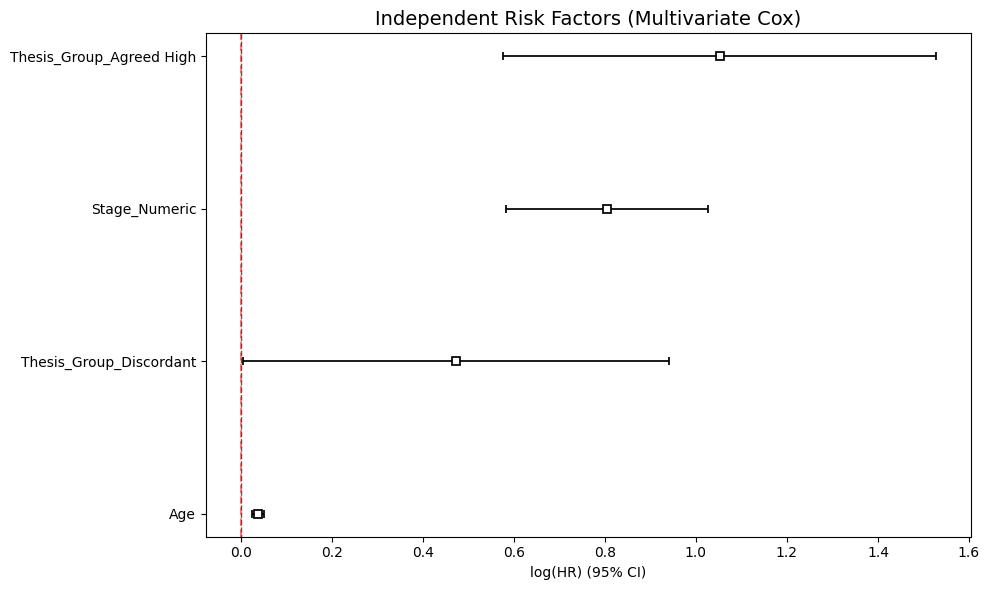

In [22]:
# 1. Prepare the multivariate dataset
cols_to_include = ['overall_survival', 'status', 'Thesis_Group', 'years_to_birth', 'pathologic_stage']

# CLEANING STEP: Drop rows that have ANY missing values in these columns
cox_multi_df = plot_df[cols_to_include].dropna().copy()

# 2. Pre-process Clinical Variables
cox_multi_df['Age'] = cox_multi_df['years_to_birth'].abs()

def simplify_stage(s):
    s = str(s).upper()
    if 'IV' in s: return 4
    if 'III' in s: return 3
    if 'II' in s: return 2
    if 'I' in s: return 1
    return 2 # Median fallback

cox_multi_df['Stage_Numeric'] = cox_multi_df['pathologic_stage'].apply(simplify_stage)

# 3. Create Dummy Variables
# Ensure we are using the freshly cleaned cox_multi_df
cox_final = pd.get_dummies(
    cox_multi_df[['overall_survival', 'status', 'Thesis_Group', 'Age', 'Stage_Numeric']], 
    columns=['Thesis_Group'], 
    drop_first=False
)

# Drop baseline
if 'Thesis_Group_Agreed Low' in cox_final.columns:
    cox_final = cox_final.drop(columns=['Thesis_Group_Agreed Low'])

# 4. Fit and Plot
print(f"Running Multivariate Cox on {len(cox_final)} complete cases...")
cph_multi = CoxPHFitter()
cph_multi.fit(cox_final, duration_col='overall_survival', event_col='status')

cph_multi.print_summary()

# 5. Visualise
plt.figure(figsize=(10, 6))
cph_multi.plot()
plt.title('Independent Risk Factors (Multivariate Cox)', fontsize=14)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Discordance Intensity Boxplots

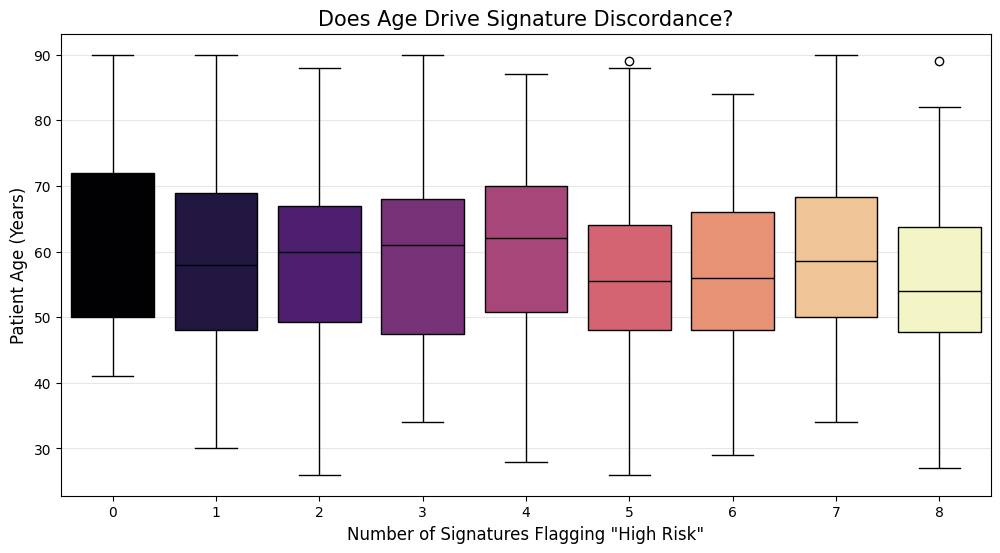

In [23]:
# 1. Ensure the High_Risk_Count is calculated
master_df['High_Risk_Count'] = master_df[class_cols].sum(axis=1)

# 2. Fix the Age column (taking absolute value just in case they are negative)
master_df['Actual_Age'] = master_df['years_to_birth'].abs()

plt.figure(figsize=(12, 6))

# 3. Use the correct column name 'Actual_Age'
sns.boxplot(
    data=master_df, 
    x='High_Risk_Count', 
    y='Actual_Age', 
    palette='magma',
    hue='High_Risk_Count', # Adding hue to avoid future warnings
    legend=False
)

plt.title('Does Age Drive Signature Discordance?', fontsize=15)
plt.xlabel('Number of Signatures Flagging "High Risk"', fontsize=12)
plt.ylabel('Patient Age (Years)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()